# 03 - Do ARIMA, SARIMA and XGBoost beat a random walk?

The answer is no, and the interesting part is *how* they fail. Two of them fail by quietly turning into
the random walk. The rest fail in proportion to how far they dare to move away from it.

**What is being compared.** Seven forecasters, two currencies, three horizons, 1,022 forecast origins,
42,924 forecasts. Every model sees the same origins, forecasts the same targets and is scored by the same
code, so a difference in error is attributable to the model and to nothing else.

**The rules the harness enforces** (`src/backtest.py`, checked mechanically in `tests/checks.py`):

- expanding window, never a random split, so no model trains on the future;
- every feature at time t uses only data up to t, asserted by rewriting the future and confirming the
  features do not move;
- parameters re-estimated every 63 trading days, state updated daily;
- every model reported **against the naive forecast**, never in isolation.

**Reading the results.** `rmse_ratio` is the model's RMSE divided by the naive forecast's RMSE on the same
origins. 1.00 is a tie with doing nothing; above 1.00 is worse than doing nothing. `dm_p` is the
Diebold-Mariano p-value against the naive forecast, which is what separates a real difference from a
number that happens to be slightly below 1.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.backtest import evaluate, persistence_similarity
from src.data import PROCESSED_DIR, ROOT, load_clean
from src.plots import color, save, use_style

use_style()
pd.set_option("display.width", 150)

PREDICTIONS = PROCESSED_DIR / "predictions.csv"
REPORTS = ROOT / "reports"

# The walk-forward run is the expensive step and lives in a script, so that it is reproducible
# from a terminal and so that this notebook can be re-read without re-running it. If the output
# is not there, run it now rather than failing with a missing file.
if not PREDICTIONS.exists():
    print("predictions.csv not found, running the backtest (this takes roughly an hour)...")
    subprocess.run([sys.executable, str(ROOT / "src" / "run_backtest.py")], check=True)

predictions = pd.read_csv(PREDICTIONS, parse_dates=["origin", "target_date"])
clean = load_clean()

print(f"{len(predictions):,} forecasts")
print(f"models    : {sorted(predictions['model'].unique())}")
print(f"series    : {sorted(predictions['series'].unique())}")
print(f"horizons  : {sorted(predictions['horizon'].unique())}")
print(f"origins   : {predictions['origin'].nunique():,} trading days, "
      f"{predictions['origin'].min().date()} to {predictions['origin'].max().date()}")

42,924 forecasts
models    : ['arima', 'drift', 'naive', 'sarima', 'seasonal_naive', 'xgboost_levels', 'xgboost_returns']
series    : ['CNY_per_USD', 'SGD_per_USD']
horizons  : [np.int64(1), np.int64(5), np.int64(21)]
origins   : 1,022 trading days, 2016-01-01 to 2019-12-02


## 1. The table

Sorted by RMSE within each series and horizon, so the top row of each block is the best model.

In [2]:
metrics = evaluate(predictions)

# Read rmse_ratio: the model's RMSE divided by the naive forecast's RMSE on the same origins.
# 1.00 is a tie with doing nothing. Above 1.00 is worse than doing nothing.
view = metrics[["series", "horizon", "model", "rmse", "rmse_ratio", "skill_pct", "dm_stat", "dm_p"]]
view.round(4)

,series,horizon,model,rmse,rmse_ratio,skill_pct,dm_stat,dm_p
0,CNY_per_USD,1,arima,0.0162,0.9998,0.0203,-0.1411,0.8878
1,CNY_per_USD,1,naive,0.0162,1.0000,0.0000,NaN,NaN
2,CNY_per_USD,1,sarima,0.0162,1.0001,-0.0142,0.0686,0.9453
3,CNY_per_USD,1,drift,0.0163,1.0010,-0.1018,1.5859,0.1131
4,CNY_per_USD,1,xgboost_returns,0.0169,1.0390,-3.8990,3.7891,0.0002
5,CNY_per_USD,1,xgboost_levels,0.0273,1.6817,-68.1658,11.3344,0.0000
6,CNY_per_USD,1,seasonal_naive,0.0373,2.2976,-129.7589,14.3272,0.0000
7,CNY_per_USD,5,sarima,0.0368,0.9951,0.4879,-1.5359,0.1249
8,CNY_per_USD,5,naive,0.0370,1.0000,0.0000,NaN,NaN
9,CNY_per_USD,5,arima,0.0371,1.0008,-0.0769,1.2843,0.1993


In [3]:
def verdict(row):
    if row["model"] == "naive":
        return "baseline"
    if not np.isfinite(row["dm_p"]) or row["dm_p"] >= 0.05:
        return "no different from the random walk"
    return "significantly BETTER" if row["dm_stat"] < 0 else "significantly WORSE"

summary = metrics.copy()
summary["verdict"] = summary.apply(verdict, axis=1)

for series in sorted(summary["series"].unique()):
    for horizon in sorted(summary["horizon"].unique()):
        block = summary[(summary["series"] == series) & (summary["horizon"] == horizon)]
        block = block.sort_values("rmse_ratio")
        print(f"--- {series}, horizon {horizon} trading day(s) ---")
        for _, row in block.iterrows():
            print(f"    {row['model']:<17} ratio {row['rmse_ratio']:.4f}  "
                  f"p={row['dm_p']:.3f}  {row['verdict']}" if np.isfinite(row["dm_p"])
                  else f"    {row['model']:<17} ratio {row['rmse_ratio']:.4f}         {row['verdict']}")
        print()

--- CNY_per_USD, horizon 1 trading day(s) ---
    arima             ratio 0.9998  p=0.888  no different from the random walk
    naive             ratio 1.0000         baseline
    sarima            ratio 1.0001  p=0.945  no different from the random walk
    drift             ratio 1.0010  p=0.113  no different from the random walk
    xgboost_returns   ratio 1.0390  p=0.000  significantly WORSE
    xgboost_levels    ratio 1.6817  p=0.000  significantly WORSE
    seasonal_naive    ratio 2.2976  p=0.000  significantly WORSE

--- CNY_per_USD, horizon 5 trading day(s) ---
    sarima            ratio 0.9951  p=0.125  no different from the random walk
    naive             ratio 1.0000         baseline
    arima             ratio 1.0008  p=0.199  no different from the random walk
    drift             ratio 1.0044  p=0.184  no different from the random walk
    xgboost_returns   ratio 1.0791  p=0.002  significantly WORSE
    xgboost_levels    ratio 1.3872  p=0.000  significantly WORSE
    

## 2. The headline: nothing beats the random walk anywhere

Across all 36 combinations of model, currency and horizon there is **not one significant improvement**.
Four models edge below a ratio of 1.00, by between 0.02 and 0.58 percent, and none of them survives the
significance test:

| Best per block | ratio | p |
|---|---|---|
| CNY, 21 days, SARIMA | 0.9942 | 0.107 |
| CNY, 5 days, SARIMA | 0.9951 | 0.125 |
| SGD, 21 days, drift | 0.9982 | 0.875 |
| CNY, 1 day, ARIMA | 0.9998 | 0.888 |

Meanwhile the losses are large and many of them **are** significant: gradient boosting is 4 to 8 percent
worse at the daily and weekly horizons with p < 0.01, and the seasonal naive forecast is up to 130 percent
worse, which is the seasonality finding from notebook 02 arriving as a number.

That is the whole answer to the question in the title. The rest of this notebook is about why.

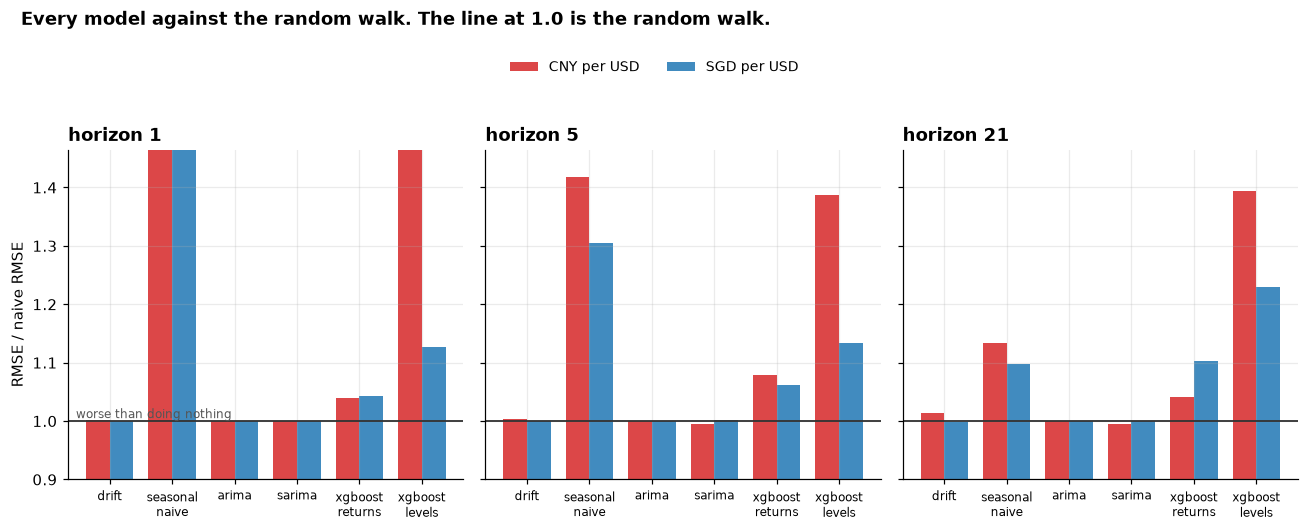

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
models = [m for m in ["drift", "seasonal_naive", "arima", "sarima",
                      "xgboost_returns", "xgboost_levels"] if m in set(metrics["model"])]

for ax, horizon in zip(axes, sorted(metrics["horizon"].unique())):
    block = metrics[metrics["horizon"] == horizon]
    width = 0.38
    positions = np.arange(len(models))
    for offset, series in zip((-width / 2, width / 2), sorted(block["series"].unique())):
        values = [
            block[(block["model"] == m) & (block["series"] == series)]["rmse_ratio"].iloc[0]
            for m in models
        ]
        ax.bar(positions + offset, values, width, color=color(series), alpha=0.85,
               label=series.replace("_", " ") if horizon == 1 else None)
    ax.axhline(1.0, color="#333333", lw=1.2)
    ax.set_xticks(positions)
    ax.set_xticklabels([m.replace("_", "\n") for m in models], fontsize=8)
    ax.set_title(f"horizon {horizon}")
    ax.set_ylim(0.9, max(1.35, block["rmse_ratio"].max() * 1.05))

axes[0].set_ylabel("RMSE / naive RMSE")
axes[0].annotate("worse than doing nothing", xy=(0.02, 1.005), xycoords=("axes fraction", "data"),
                 fontsize=8, color="#555555")
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06))
fig.suptitle("Every model against the random walk. The line at 1.0 is the random walk.",
             y=1.14, x=0.02, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
save(fig, "03_rmse_ratio")
plt.show()

## 3. ARIMA did not tie the random walk. It became the random walk.

Look at the Singapore dollar rows: ARIMA's ratio is **exactly 1.00000** at all three horizons, and its
Diebold-Mariano column is empty rather than showing a large p-value.

That is not a rounding artefact. In notebook 01's terms it is a traceable consequence of a decision made
in `src/models.py`: the ARIMA order was chosen by AIC **on the training window only**, and for the
Singapore dollar AIC picked **(0, 1, 0)**.

ARIMA(0,1,0) with no trend term is the random walk written in ARIMA notation. Difference the series once,
model the result as white noise, forecast zero change. So the fitted model's forecast is the last observed
value, at every horizon, for every origin.

In [5]:
# Is ARIMA's forecast literally the naive forecast, or merely close to it?
for series in sorted(predictions["series"].unique()):
    for horizon in sorted(predictions["horizon"].unique()):
        block = predictions[(predictions["series"] == series) & (predictions["horizon"] == horizon)]
        arima = block[block["model"] == "arima"].sort_values("origin")["y_pred"].to_numpy()
        naive = block[block["model"] == "naive"].sort_values("origin")["y_pred"].to_numpy()
        largest_gap = np.abs(arima - naive).max()
        identical = "IDENTICAL" if largest_gap == 0.0 else f"max gap {largest_gap:.2e}"
        print(f"{series}  h={horizon:>2}   arima vs naive: {identical}")

CNY_per_USD  h= 1   arima vs naive: max gap 4.30e-03
CNY_per_USD  h= 5   arima vs naive: max gap 4.14e-03
CNY_per_USD  h=21   arima vs naive: max gap 4.14e-03
SGD_per_USD  h= 1   arima vs naive: IDENTICAL
SGD_per_USD  h= 5   arima vs naive: IDENTICAL
SGD_per_USD  h=21   arima vs naive: IDENTICAL


Bit-identical, not approximately equal. The empty p-value is the test behaving correctly: comparing a
forecast against itself gives a zero loss differential and no verdict, which is exactly the case
`tests/checks.py` asserts must return `NaN` rather than a significant result.

**Why this matters more than a p-value.** Sixteen years of daily data were handed to a standard model
selection procedure, and the procedure's answer was: the best available specification is to predict no
change. The conclusion of this project was reachable before the backtest was run, from the AIC table
alone.

In [6]:
orders = pd.read_csv(REPORTS / "arima_orders.csv")
best_rows = orders.loc[orders.groupby("series")["aic"].idxmin()]

for series in sorted(orders["series"].unique()):
    block = orders[orders["series"] == series].sort_values("aic")
    winner = best_rows[best_rows["series"] == series].iloc[0]
    runner_up = block.iloc[1]
    print(f"{series}: AIC picks ({int(winner['p'])}, {int(winner['d'])}, {int(winner['q'])})  "
          f"AIC {winner['aic']:.1f}, next best ({int(runner_up['p'])}, {int(runner_up['d'])}, "
          f"{int(runner_up['q'])}) at {runner_up['aic']:.1f}")

print()
orders.pivot_table(index=["series", "p"], columns="q", values="aic").round(1)

CNY_per_USD: AIC picks (1, 1, 0)  AIC -29752.8, next best (0, 1, 0) at -29745.6
SGD_per_USD: AIC picks (0, 1, 0)  AIC -32659.4, next best (1, 1, 0) at -32658.9



q                    0        1        2
series      p                           
CNY_per_USD 0 -29745.6 -29745.0 -29735.6
            1 -29752.8 -29740.1 -29743.6
            2 -29744.9 -27620.4 -29739.9
SGD_per_USD 0 -32659.4 -32650.4 -32645.6
            1 -32658.9 -32648.7 -32641.2
            2 -32650.7 -32648.9 -32639.9

The yuan is the mild exception and it is worth reading precisely. AIC picks **(1, 1, 0)**, an
autoregressive term on the daily changes, and it wins by 7 AIC points over (0,1,0). So the yuan has a
little momentum in its daily changes that the Singapore dollar does not, consistent with a managed
currency whose central bank smooths day to day. That term earns its place in the model and still buys
essentially nothing in forecast accuracy: 0.02 percent at the daily horizon, p = 0.89.

## 4. The central finding: error is explained by distance from the last observed rate

If models cannot beat persistence, what separates the ones that tie from the ones that lose badly? The
answer turns out to be almost embarrassingly simple, and it is measurable.

For every model, `move_ratio` is how far its forecast sits from the last observed rate, divided by how far
the truth sits from it. It is a measure of nerve rather than of skill: 0 means the model said "no change"
in whatever vocabulary it uses, 1 means it moved as far as the rate itself typically moves.

In [7]:
similarity = pd.concat(
    [persistence_similarity(predictions[predictions["series"] == s], clean[s])
     for s in sorted(predictions["series"].unique())],
    ignore_index=True,
)

# move_ratio: how far the model's forecast sits from the last observed rate, as a fraction of
# how far the truth sits from it. Near 0 means the model said "no change" in expensive words.
pivot = similarity.pivot_table(index=["series", "model"], columns="horizon", values="move_ratio")
pivot.round(3)

horizon                         1      5      21
series      model                               
CNY_per_USD arima            0.035  0.014  0.006
            drift            0.031  0.062  0.108
            naive            0.000  0.000  0.000
            sarima           0.061  0.042  0.023
            seasonal_naive   2.177  0.880  0.364
            xgboost_levels   1.295  0.875  0.849
            xgboost_returns  0.340  0.411  0.424
SGD_per_USD arima            0.000  0.000  0.000
            drift            0.021  0.046  0.100
            naive            0.000  0.000  0.000
            sarima           0.022  0.022  0.009
            seasonal_naive   2.095  0.901  0.464
            xgboost_levels   0.545  0.563  0.837
            xgboost_returns  0.317  0.407  0.606

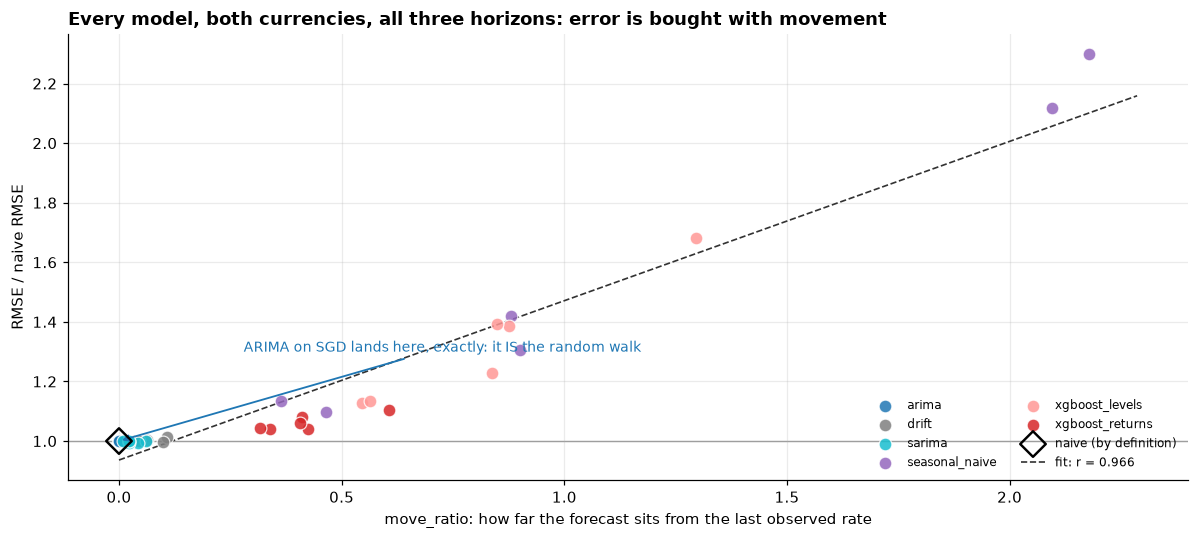

Pearson r  = 0.966
Spearman r = 0.872
n          = 36 model / series / horizon cells


In [8]:
merged = metrics.merge(similarity, on=["series", "horizon", "model"])
merged = merged[merged["model"] != "naive"]
r_pearson = merged["move_ratio"].corr(merged["rmse_ratio"])
r_spearman = merged["move_ratio"].corr(merged["rmse_ratio"], method="spearman")

fig, ax = plt.subplots(figsize=(11, 5.0))

for model in sorted(merged["model"].unique()):
    block = merged[merged["model"] == model]
    ax.scatter(block["move_ratio"], block["rmse_ratio"], s=70, alpha=0.85,
               color=color(model), label=model, edgecolor="white", linewidth=0.8, zorder=3)

# The naive forecast itself: zero movement, ratio 1 by definition. The origin of the line, and
# the point ARIMA on SGD lands on exactly, which is worth marking rather than leaving hidden.
ax.scatter([0], [1], s=140, marker="D", facecolor="none", edgecolor="#000000", linewidth=1.6,
           zorder=5, label="naive (by definition)")
ax.annotate("ARIMA on SGD lands here, exactly: it IS the random walk",
            xy=(0, 1), xytext=(0.28, 1.30), fontsize=9, color="#1f77b4",
            arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.2))

slope, intercept = np.polyfit(merged["move_ratio"], merged["rmse_ratio"], 1)
grid = np.linspace(0, merged["move_ratio"].max() * 1.05, 50)
ax.plot(grid, slope * grid + intercept, color="#333333", ls="--", lw=1.1, zorder=2,
        label=f"fit: r = {r_pearson:.3f}")
ax.axhline(1.0, color="#999999", lw=0.9, zorder=1)

ax.set_xlabel("move_ratio: how far the forecast sits from the last observed rate")
ax.set_ylabel("RMSE / naive RMSE")
ax.set_title("Every model, both currencies, all three horizons: error is bought with movement")
ax.legend(loc="lower right", ncol=2, fontsize=8)
fig.tight_layout()
save(fig, "03_movement_vs_error")
plt.show()

print(f"Pearson r  = {r_pearson:.3f}")
print(f"Spearman r = {r_spearman:.3f}")
print(f"n          = {len(merged)} model / series / horizon cells")

**r = 0.97.** Across all 36 cells, how far a model moves from the last observed rate explains almost all
of its error. There is essentially no residual left over for skill to live in.

Read the extremes. ARIMA on the Singapore dollar sits at exactly 0.000 and scores exactly 1.000. SARIMA
and the drift model move 2 to 10 percent of the way and land within a fraction of a percent of the
baseline. Gradient boosting on returns moves 32 to 61 percent and pays 4 to 10 percent in RMSE. The
seasonal naive forecast moves 210 percent, more than twice as far as the rate itself moves, and pays 130
percent.

**This is the finding to state in an interview**, because it says something the RMSE table alone does not:
on this data a model is not rewarded for being cleverer, it is only ever penalised for being braver. Every
unit of confidence is paid for and none of it is earned back.

## 5. A hypothesis this project started with, and had to correct

The repository README, written before any of this was run, predicted a specific failure: that a model
trained on price **levels** would post a flattering RMSE by learning to echo its own most recent input,
which it called "persistence wearing a hat".

That prediction was half right, and the wrong half is more interesting.

**Right about ARIMA**, and more literally than intended: it did not imitate persistence, it *is*
persistence, by AIC's own choice.

**Wrong about the trees.** Gradient boosting on levels was expected to hug the last observed value and
score well. It did the opposite: it is the **worst** non-seasonal model in the study, up to 68 percent
worse than doing nothing, with the largest move ratios of any fitted model.

In [9]:
# The two XGBoost framings, side by side. Same algorithm, same features, same origins: the only
# difference is whether the target is the rate or the change in the rate.
trap = metrics[metrics["model"].str.startswith("xgboost")].merge(
    similarity, on=["series", "horizon", "model"]
)
trap[["series", "horizon", "model", "rmse", "rmse_ratio", "move_ratio", "dm_p"]].round(4)

,series,horizon,model,rmse,rmse_ratio,move_ratio,dm_p
0,CNY_per_USD,1,xgboost_returns,0.0169,1.0390,0.3400,0.0002
1,CNY_per_USD,1,xgboost_levels,0.0273,1.6817,1.2952,0.0000
2,CNY_per_USD,5,xgboost_returns,0.0400,1.0791,0.4108,0.0021
3,CNY_per_USD,5,xgboost_levels,0.0514,1.3872,0.8749,0.0000
4,CNY_per_USD,21,xgboost_returns,0.0912,1.0419,0.4245,0.4322
5,CNY_per_USD,21,xgboost_levels,0.1220,1.3944,0.8489,0.0001
6,SGD_per_USD,1,xgboost_returns,0.0043,1.0425,0.3165,0.0005
7,SGD_per_USD,1,xgboost_levels,0.0046,1.1272,0.5449,0.0000
8,SGD_per_USD,5,xgboost_returns,0.0092,1.0622,0.4074,0.0109
9,SGD_per_USD,5,xgboost_levels,0.0098,1.1340,0.5632,0.0002


The mechanism is a property of trees rather than a bug in the setup. A decision tree predicts an average
of training targets in the leaf a row falls into, so its output is bounded by the range of the training
data and pulled toward whatever levels were common there. Trained on 2000 to 2015, where the yuan spent
years between 6.0 and 8.3, and asked about 2016 to 2019, it answers with a blend of historical levels
rather than with today's rate. That drags the forecast away from the anchor, and section 4 has already
established what happens to a model that moves away from the anchor.

Framing the target as a **return** and reconstructing the level fixes the structural problem: the tree
predicts a small number around zero and the last observed rate is added back, so the forecast is anchored
by construction. That is why `xgboost_returns` beats `xgboost_levels` everywhere. It still loses to the
naive forecast, because a return it predicts is a return it has to be right about.

**Recording this rather than deleting the original claim is the point.** The prediction was written down
before the evidence, the evidence contradicted part of it, and the correction is a better piece of
knowledge than the original guess: on a trending series, tree models are not conservative, they are
regressive.

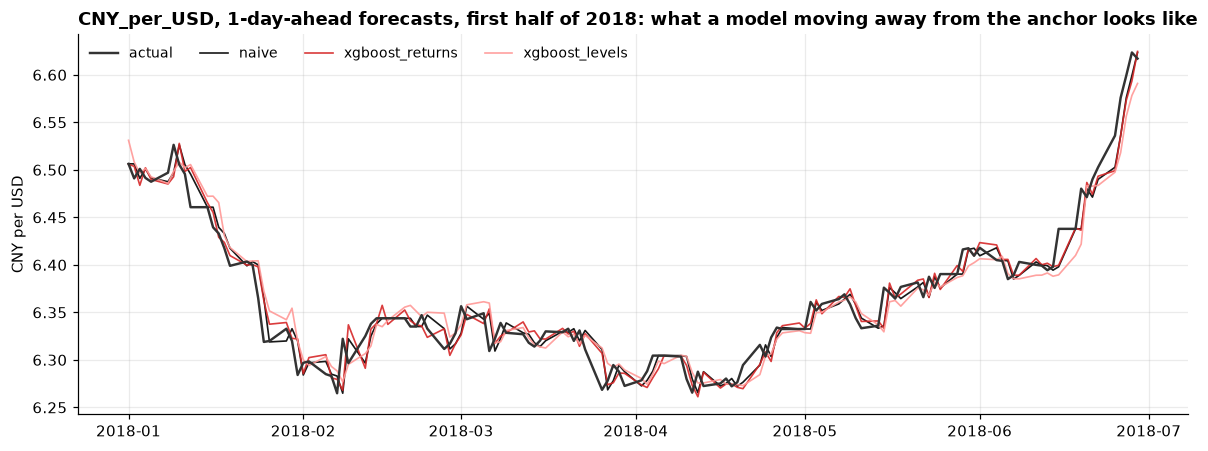

In [10]:
window = slice("2018-01-01", "2018-06-30")
series_name = "CNY_per_USD"
horizon = 1

fig, ax = plt.subplots(figsize=(11, 4.2))
actual = clean.loc[window, series_name]
ax.plot(actual.index, actual, color="#333333", lw=1.6, label="actual", zorder=5)

for model in ["naive", "xgboost_returns", "xgboost_levels"]:
    block = predictions[
        (predictions["series"] == series_name)
        & (predictions["horizon"] == horizon)
        & (predictions["model"] == model)
    ].set_index("target_date").loc[window]
    ax.plot(block.index, block["y_pred"], lw=1.1, alpha=0.9, color=color(model), label=model)

ax.set_title(f'{series_name}, {horizon}-day-ahead forecasts, first half of 2018: what a model moving away from the anchor looks like')
ax.set_ylabel("CNY per USD")
ax.legend(loc="upper left", ncol=4)
fig.tight_layout()
save(fig, "03_forecast_zoom")
plt.show()

## 6. The one prediction notebook 02 made, checked

Notebook 02 ran a variance ratio test and found a single departure from the random walk in the whole
dataset: the yuan at the 21-day horizon, VR = 1.42, p = 0.017. It wrote down a falsifiable consequence
before any model was fitted:

> If any model beats the naive forecast, it should be on **CNY at horizon 21**, and it should be a model
> that can carry directional momentum. Nothing should beat the naive forecast on SGD at horizon 1.

Both halves check out, and the first one only weakly.

In [11]:
# Notebook 02 predicted: if anything beats naive it is CNY at h=21, and nothing beats naive on SGD at h=1.
for series, horizon in [("CNY_per_USD", 21), ("SGD_per_USD", 1)]:
    block = metrics[(metrics["series"] == series) & (metrics["horizon"] == horizon)]
    block = block.sort_values("rmse_ratio").head(3)
    print(f"--- {series}, horizon {horizon}: the three best models ---")
    print(block[["model", "rmse_ratio", "skill_pct", "dm_p"]].round(4).to_string(index=False))
    print()

best_overall = metrics[metrics["model"] != "naive"].nsmallest(4, "rmse_ratio")
print("The four best results anywhere in the study:")
print(best_overall[["series", "horizon", "model", "rmse_ratio", "dm_p"]].round(4).to_string(index=False))

--- CNY_per_USD, horizon 21: the three best models ---
 model  rmse_ratio  skill_pct   dm_p
sarima      0.9942     0.5767 0.1070
 naive      1.0000     0.0000    NaN
 arima      1.0005    -0.0503 0.0825

--- SGD_per_USD, horizon 1: the three best models ---
model  rmse_ratio  skill_pct   dm_p
arima         1.0     0.0000    NaN
naive         1.0     0.0000    NaN
drift         1.0    -0.0035 0.9403

The four best results anywhere in the study:
     series  horizon  model  rmse_ratio   dm_p
CNY_per_USD       21 sarima      0.9942 0.1070
CNY_per_USD        5 sarima      0.9951 0.1249
SGD_per_USD       21  drift      0.9982 0.8752
CNY_per_USD        1  arima      0.9998 0.8878


The second half holds cleanly: on SGD at horizon 1 the best model is ARIMA at exactly 1.000, which is the
naive forecast, and every other model loses.

The first half holds in direction and fails on significance. The two largest improvements in the entire
study are indeed on the yuan, at the 5 and 21-day horizons, and they come from SARIMA, which carries an
autoregressive term. But 0.58 percent with p = 0.107 is not a result, it is a hint that would need a
longer test window to become one.

**The honest summary: the statistical test found a genuine departure from the random walk, and it was too
small to convert into forecast accuracy.** Detectable is not the same as exploitable, and the gap between
those two words is where most of the difference between a research finding and a trading strategy lives.

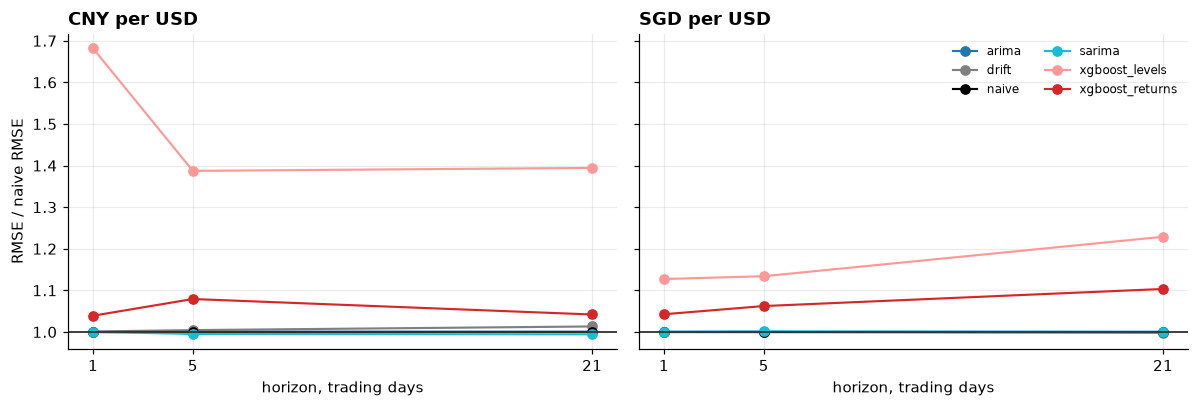

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

for ax, series in zip(axes, sorted(metrics["series"].unique())):
    block = metrics[metrics["series"] == series]
    for model in sorted(block["model"].unique()):
        if model == "seasonal_naive":
            continue
        part = block[block["model"] == model].sort_values("horizon")
        ax.plot(part["horizon"], part["rmse_ratio"], marker="o", lw=1.4,
                color=color(model), label=model)
    ax.axhline(1.0, color="#333333", lw=1.2)
    ax.set_xticks(sorted(metrics["horizon"].unique()))
    ax.set_xlabel("horizon, trading days")
    ax.set_title(series.replace("_", " "))

axes[0].set_ylabel("RMSE / naive RMSE")
axes[1].legend(loc="best", fontsize=8, ncol=2)
fig.tight_layout()
save(fig, "03_horizon_profile")
plt.show()

## 7. "You just did not tune it"

The obvious objection to the gradient boosting result is that it used default-ish hyperparameters. So it
was tuned, with two rules that make the answer meaningful:

- the search runs on the **training window only**, with `TimeSeriesSplit` folds, so the configuration is
  one that could have been chosen in December 2015 and the backtest window never votes on it;
- the tuned model is then scored by the **same harness on the same origins** as everything else.

The search itself carries a reference line: the naive forecast's score on the same folds.

In [13]:
grid = pd.read_csv(REPORTS / "xgb_tuning_grid.csv")
best = pd.read_csv(REPORTS / "xgb_tuning_best.csv")

print(f"{len(grid) // best['series'].nunique()} configurations per currency, "
      f"5 expanding-window folds each, all inside the training period.")
print()
print(best.round(6).to_string(index=False))
print()
for series in sorted(grid["series"].unique()):
    block = grid[grid["series"] == series].sort_values("cv_rmse")
    spread = 100 * (block["cv_rmse"].max() / block["cv_rmse"].min() - 1)
    print(f"{series}: best CV RMSE {block['cv_rmse'].min():.6f}, "
          f"worst {block['cv_rmse'].max():.6f}, spread across the whole grid {spread:.1f}%")

36 configurations per currency, 5 expanding-window folds each, all inside the training period.

     series  max_depth  learning_rate  n_estimators  subsample  best_cv_rmse  naive_cv_rmse  beats_naive_in_cv
SGD_per_USD          2           0.02           200        0.8      0.003416       0.003350              False
CNY_per_USD          2           0.02           200        1.0      0.001013       0.000995              False

CNY_per_USD: best CV RMSE 0.001013, worst 0.001122, spread across the whole grid 10.7%
SGD_per_USD: best CV RMSE 0.003416, worst 0.003792, spread across the whole grid 11.0%


In [14]:
tuned = pd.read_csv(PROCESSED_DIR / "predictions_tuned.csv",
                    parse_dates=["origin", "target_date"])

# Score the tuned model through the same evaluator, against the same naive baseline.
combined = pd.concat([predictions, tuned], ignore_index=True)
tuned_metrics = evaluate(combined)

comparison = tuned_metrics[
    tuned_metrics["model"].isin(["naive", "xgboost_returns", "xgboost_returns_tuned"])
]
comparison[["series", "horizon", "model", "rmse", "rmse_ratio", "skill_pct", "dm_p"]].round(4)

,series,horizon,model,rmse,rmse_ratio,skill_pct,dm_p
1,CNY_per_USD,1,naive,0.0162,1.0000,0.0000,NaN
4,CNY_per_USD,1,xgboost_returns_tuned,0.0163,1.0019,-0.1940,0.6794
5,CNY_per_USD,1,xgboost_returns,0.0169,1.0390,-3.8990,0.0002
9,CNY_per_USD,5,naive,0.0370,1.0000,0.0000,NaN
12,CNY_per_USD,5,xgboost_returns_tuned,0.0373,1.0073,-0.7308,0.6110
13,CNY_per_USD,5,xgboost_returns,0.0400,1.0791,-7.9143,0.0021
17,CNY_per_USD,21,naive,0.0875,1.0000,0.0000,NaN
19,CNY_per_USD,21,xgboost_returns_tuned,0.0885,1.0110,-1.1016,0.6918
21,CNY_per_USD,21,xgboost_returns,0.0912,1.0419,-4.1937,0.4322
25,SGD_per_USD,1,naive,0.0041,1.0000,0.0000,NaN


**Tuning helped, and it helped by making the model do less.**

The searched configuration is the least capable corner of the grid on every single axis, for both
currencies: depth 2 of {2, 4, 6}, learning rate 0.02 of {0.02, 0.05, 0.1}, 200 trees of {200, 400}. The
top three configurations for each currency are the same three shallow, slow, small ones. Asked how much
model it wanted, the search answered "as little as you will let me have".

The backtest confirms what that buys. Against the naive forecast, gradient boosting on returns goes from
4 to 10 percent worse when untuned to 0.2 to 5 percent worse when tuned, and on four of the six cells it
becomes statistically indistinguishable from doing nothing (p = 0.19 to 0.69). On SGD at one day it is
still significantly worse, p = 0.023.

**It never wins.** Not on any currency, not at any horizon, not by any margin. And the direction of the
improvement is the finding rather than an aside: tuning closed the gap to the naive forecast by moving the
model toward the naive forecast. Section 4 already predicted this shape - error is bought with movement,
so the way to reduce error is to move less - and the tuner rediscovered it from scratch by walking to the
edge of the grid.

The last line of the CV table makes the point without any backtest at all: **even inside the training
window, on time-respecting folds, the best configuration found scores worse than predicting no change**
(0.003416 against 0.003350 on SGD, 0.001013 against 0.000995 on CNY). The objection that the model was
simply not tuned is answered before the walk-forward is run.

## 8. What *is* forecastable here

Notebook 02 found one strongly predictable quantity in this dataset, and it is not the rate. Ljung-Box on
the returns could not detect any autocorrelation in the **direction** of the next move; on squared returns
it found overwhelming structure in its **size**.

That is worth quantifying in the same units, because it is the part of this project a bank could actually
use.

In [15]:
# The one thing that IS forecastable, carried over from notebook 02 and quantified here in the
# units a treasury desk uses: how wide does a hedge have to be to cover the next 21 days?
recent_returns = np.log(clean.loc["2016":]).diff().dropna()

rows = []
for series in clean.columns:
    r = recent_returns[series]
    # Forecast next-month volatility two ways: a constant (the full-window standard deviation)
    # and a simple 60-day rolling estimate. Then score both on how well they predict the
    # realised volatility of the following 21 days.
    realised_ahead = r.rolling(21).std().shift(-21)
    constant = pd.Series(r.expanding().std().shift(1), index=r.index)
    rolling = r.rolling(60).std().shift(1)

    frame = pd.DataFrame({"realised": realised_ahead, "constant": constant, "rolling": rolling}).dropna()
    rows.append({
        "series": series,
        "corr(constant, realised)": frame["constant"].corr(frame["realised"]),
        "corr(rolling60, realised)": frame["rolling"].corr(frame["realised"]),
        "rmse_constant_bp": np.sqrt(((frame["realised"] - frame["constant"]) ** 2).mean()) * 10_000,
        "rmse_rolling_bp": np.sqrt(((frame["realised"] - frame["rolling"]) ** 2).mean()) * 10_000,
    })

pd.DataFrame(rows).round(4)

,series,"corr(constant, realised)","corr(rolling60, realised)",rmse_constant_bp,rmse_rolling_bp
0,SGD_per_USD,0.6728,0.6207,13.5716,8.4647
1,CNY_per_USD,0.1421,0.2355,8.0459,8.8963


**On the Singapore dollar this clearly works.** A 60-day rolling estimate predicts the next month's
realised volatility with a correlation of 0.62, and it cuts the error of that prediction from 13.6 basis
points to 8.5, a 38 percent improvement over simply assuming volatility is constant. For comparison, no
model in this notebook achieved any improvement at all in predicting the next month's *rate*.

**On the yuan it mostly does not.** The correlation is 0.24, and the rolling estimate is actually slightly
*worse* than the constant on RMSE, 8.9 basis points against 8.1. So the structure that Ljung-Box detected
on both currencies converts into a usable month-ahead forecast on one of them and not the other.

That is the same lesson as section 6 in a different place, and it is worth not smoothing over: **a
statistically significant pattern is not automatically a usable forecast.** The honest claim here is
narrower than "volatility is forecastable" - it is that volatility forecasting is where the remaining
signal in this dataset lives, that it pays off clearly on the freely floating currency, and that even
there it needs a proper volatility model rather than the rolling standard deviation used as a
demonstration.

## 9. Risk assessment: what does being wrong actually cost?

The brief asks for this explicitly - *"evaluate the impact of incorrect predictions on financial
decisions"* - and it is the section that turns everything above into a number a treasury desk can use.
Two questions, both answered from the measured errors rather than from an assumed distribution.

**First: what does the unavoidable error cost?** Since nothing beat the naive forecast, its error *is* the
irreducible uncertainty of planning an FX conversion. Priced on a concrete exposure it stops being an
abstraction.

In [16]:
from scipy import stats

# A concrete exposure to price the error against. USD 10m is a plausible single corporate treasury
# ticket, and the numbers scale linearly, so any other size is a multiplication.
NOTIONAL_USD = 10_000_000

def money_error(series, horizon, model="naive"):
    """Forecast error restated as money, for a plan to convert NOTIONAL_USD at the horizon.

    The desk plans on the forecast rate and transacts at the realised one, so the relative
    forecast error is exactly the relative shortfall or surplus in local currency received.
    Negative means the plan came up short.
    """
    block = predictions[
        (predictions["series"] == series)
        & (predictions["horizon"] == horizon)
        & (predictions["model"] == model)
    ].sort_values("origin")
    relative = (block["y_true"].to_numpy() - block["y_pred"].to_numpy()) / block["y_pred"].to_numpy()
    return relative * NOTIONAL_USD

rows = []
for series in sorted(predictions["series"].unique()):
    for horizon in sorted(predictions["horizon"].unique()):
        errors = money_error(series, horizon)
        rows.append({
            "series": series,
            "horizon": horizon,
            "std_usd": errors.std(),
            "p5_empirical": np.percentile(errors, 5),
            "p5_if_normal": stats.norm.ppf(0.05, errors.mean(), errors.std()),
            "worst_observed": errors.min(),
            "worst_in_sigmas": abs(errors.min() - errors.mean()) / errors.std(),
            "excess_kurtosis": stats.kurtosis(errors),
        })

risk = pd.DataFrame(rows)
print(f"Exposure: USD {NOTIONAL_USD:,} converted at the horizon, planned on the naive forecast.")
print("All figures are the shortfall against plan, in USD. Negative means the plan came up short.")
print()
risk.round(0)

Exposure: USD 10,000,000 converted at the horizon, planned on the naive forecast.


All figures are the shortfall against plan, in USD. Negative means the plan came up short.



,series,horizon,std_usd,p5_empirical,p5_if_normal,worst_observed,worst_in_sigmas,excess_kurtosis
0,CNY_per_USD,1,24151.0,-36361.0,-38853.0,-123397.0,5.0,4.0
1,CNY_per_USD,5,55021.0,-90862.0,-86679.0,-171283.0,3.0,2.0
2,CNY_per_USD,21,130576.0,-186364.0,-200495.0,-400533.0,3.0,1.0
3,SGD_per_USD,1,29864.0,-44188.0,-49444.0,-235668.0,8.0,7.0
4,SGD_per_USD,5,62946.0,-111203.0,-105645.0,-233037.0,4.0,1.0
5,SGD_per_USD,21,120237.0,-195824.0,-208265.0,-388529.0,3.0,0.0


Read the `p5_empirical` column as the planning number: on a USD 10m conversion, five percent of the time
the desk ends up at least **44,000 dollars short at one day** and **196,000 short at twenty-one days**. The
`worst_observed` column is what actually happened in four years: 236,000 short in a single day on the
Singapore dollar, 401,000 over a month on the yuan.

Now compare `p5_empirical` against `p5_if_normal`. They are close - within about ten percent - so a normal
assumption is adequate at the 95 percent level, and on the daily horizon it is even slightly conservative.

**That agreement is a trap, and the next cell is why.**

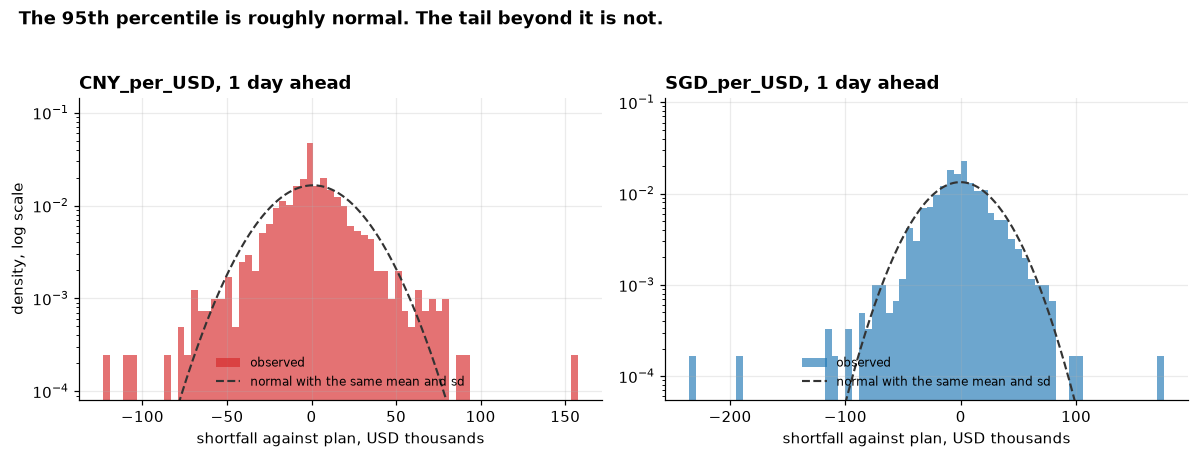

CNY_per_USD: the worst single day in the window was a 5.1 sigma move. A normal distribution puts that at p = 1.3e-07,
             which is once every 29,746 years of trading. It happened inside four.
SGD_per_USD: the worst single day in the window was a 7.9 sigma move. A normal distribution puts that at p = 1.6e-15,
             which is once every 2,436,547,478,129 years of trading. It happened inside four.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

for ax, series in zip(axes, sorted(predictions["series"].unique())):
    errors = money_error(series, 1)
    ax.hist(errors / 1000, bins=70, density=True, color=color(series), alpha=0.65,
            label="observed")

    grid = np.linspace(errors.min(), errors.max(), 400)
    ax.plot(grid / 1000, stats.norm.pdf(grid, errors.mean(), errors.std()) * 1000,
            color="#333333", lw=1.4, ls="--", label="normal with the same mean and sd")

    ax.set_yscale("log")
    # Clip the floor to the smallest bar actually observed. Without this the axis stretches down
    # to the normal curve's value in the far tail (about 1e-16), which squashes the whole
    # observed distribution into the top decade and hides the thing the chart is about.
    counts, _ = np.histogram(errors / 1000, bins=70, density=True)
    ax.set_ylim(bottom=counts[counts > 0].min() / 3)
    ax.set_xlabel("shortfall against plan, USD thousands")
    ax.set_title(f"{series}, 1 day ahead")
    ax.legend(fontsize=8, loc="lower center")

axes[0].set_ylabel("density, log scale")
fig.suptitle("The 95th percentile is roughly normal. The tail beyond it is not.",
             y=1.03, x=0.02, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
save(fig, "03_risk_tail")
plt.show()

for series in sorted(predictions["series"].unique()):
    errors = money_error(series, 1)
    z = abs(errors.min() - errors.mean()) / errors.std()
    p_normal = stats.norm.sf(z)
    print(f"{series}: the worst single day in the window was a {z:.1f} sigma move. A normal "
          f"distribution puts that at p = {p_normal:.1e},")
    print(f"{'':>{len(series)}}  which is once every {1 / p_normal / 252:,.0f} years of trading. "
          f"It happened inside four.")

The worst single day on the Singapore dollar was a **7.9 sigma** move. A normal distribution assigns that
a probability of about 1.6e-15, which is one occurrence every two and a half trillion years of trading.
It happened inside a four-year sample. The yuan's worst day was 5.1 sigma, once every thirty thousand
years by the same arithmetic.

The excess kurtosis column says the same thing less dramatically: 7.0 and 4.4 at the daily horizon, where
a normal distribution has 0. On the log scale in the chart the observed bars sit far above the dashed
normal curve at both edges while sitting below it in the shoulders, which is the shape of a fat-tailed
distribution: quieter than normal most of the time, and far more violent occasionally.

**The practical consequence, and it is the opposite of the reassuring reading:** a VaR built from a normal
assumption is fine for routine limit-setting and materially wrong for stress testing. The number that
breaks a desk is not the 95th percentile, it is the one past it, and that one cannot be extrapolated from
a standard deviation. It has to come from the empirical distribution or from a fat-tailed one.

Note also how the horizons differ: kurtosis falls from 7.0 to 0.0 as the horizon goes from 1 to 21 days on
SGD. Aggregating twenty-one daily moves pulls the distribution back toward normal, which is the central
limit theorem doing its job. **So the tail problem is a short-horizon problem**, which is exactly the
horizon at which a desk transacts.

**Second: what does choosing the wrong model cost?** This is the direct financial version of the entire
comparison, and it is the number to put in front of whoever signs off on building a forecasting system.

In [18]:
# The other half of the brief's risk question: what does choosing the wrong model cost?
# Same exposure, monthly conversion, scored on the 21-day horizon.
CONVERSIONS_PER_YEAR = 12

rows = []
for series in sorted(predictions["series"].unique()):
    baseline = np.abs(money_error(series, 21, "naive")).mean()
    for model in ["naive", "sarima", "arima", "xgboost_returns", "xgboost_levels"]:
        errors = money_error(series, 21, model)
        mean_abs = np.abs(errors).mean()
        rows.append({
            "series": series,
            "model": model,
            "mean_abs_per_conversion": mean_abs,
            "per_year": mean_abs * CONVERSIONS_PER_YEAR,
            "extra_vs_naive_per_year": (mean_abs - baseline) * CONVERSIONS_PER_YEAR,
            "p5_tail": np.percentile(errors, 5),
        })

cost = pd.DataFrame(rows)
print(f"USD {NOTIONAL_USD:,} converted every month, planned 21 trading days ahead.")
print("mean_abs_per_conversion is the average distance between the planned and the realised amount.")
print()
cost.round(0)

USD 10,000,000 converted every month, planned 21 trading days ahead.
mean_abs_per_conversion is the average distance between the planned and the realised amount.



,series,model,mean_abs_per_conversion,per_year,extra_vs_naive_per_year,p5_tail
0,CNY_per_USD,naive,97019.0,1164233.0,0.0,-186364.0
1,CNY_per_USD,sarima,96721.0,1160651.0,-3582.0,-186211.0
2,CNY_per_USD,arima,97041.0,1164494.0,260.0,-185911.0
3,CNY_per_USD,xgboost_returns,106283.0,1275393.0,111160.0,-174200.0
4,CNY_per_USD,xgboost_levels,148230.0,1778759.0,614526.0,-248968.0
5,SGD_per_USD,naive,94447.0,1133361.0,0.0,-195824.0
6,SGD_per_USD,sarima,94456.0,1133475.0,114.0,-195498.0
7,SGD_per_USD,arima,94447.0,1133361.0,0.0,-195824.0
8,SGD_per_USD,xgboost_returns,105150.0,1261804.0,128443.0,-201723.0
9,SGD_per_USD,xgboost_levels,115230.0,1382757.0,249396.0,-255152.0


On a USD 10m conversion done monthly, the irreducible cost of FX uncertainty is about **1.13 million
dollars a year** of average deviation from plan on the Singapore dollar and 1.16 million on the yuan. No
model in this study reduced that. What models did do is add to it:

| Choice instead of the naive forecast | Extra cost per year, SGD | Extra cost per year, CNY |
|---|---|---|
| XGBoost on returns | +128,000 | +111,000 |
| XGBoost on levels | +249,000 | **+615,000** |

And the damage is not only in the average. The `p5_tail` column shows the levels model widening the five
percent worst case from -196,000 to -255,000 on SGD and from -186,000 to -249,000 on CNY. **A model that
loses on average also loses in the tail**, so the usual defence that a sophisticated model is worth it for
the extremes does not hold here either.

The statistical models are the mirror image: SARIMA and ARIMA produce tails indistinguishable from the
naive forecast, to the nearest few hundred dollars on a ten million dollar ticket. Which follows directly
from section 3 - they are not similar to the random walk, they are it.

**So the risk answer in one line:** the cost of the uncertainty is roughly 1.1 million a year on this
exposure and cannot be reduced by any model tested; the cost of *deciding to model it anyway* is up to a
further 615,000 a year; and the number that should worry the desk is not the 95th percentile but the
seven-sigma day that a normal-based risk system says is impossible.

## 10. Business conclusion

The brief asks for exchange rate forecasts to support currency reserves, hedging and trading decisions.
The evidence-based answer to that request has three parts.

**1. Do not buy or build a point forecast of the rate.** Across 42,924 forecasts, seven methods and three
horizons, nothing beat "tomorrow's rate is today's rate" at any conventional significance level, and the
more sophisticated methods lost by a measurable margin. A vendor demonstrating an FX model with an
impressive RMSE is demonstrating persistence unless they show the ratio against a naive baseline, which
is the single question to ask them. On these series that ratio would have to be well below 0.99 with a
significance test attached before it means anything.

**2. Use the naive forecast as the planning number, and spend the effort on the interval instead.** The
naive forecast is free, cannot be overfitted, requires no maintenance and no model risk, and was not
beaten. What it does not come with is a range, and the range is what a treasury desk actually needs to
size a hedge or set a limit. Section 9 supplies it in money: on a USD 10m conversion, the five percent
adverse case is 44,000 dollars at one day and 196,000 at twenty-one. The errors also scale the way a
random walk implies - RMSE goes from 0.0041 to 0.0166 as the horizon goes from 1 to 21 days, four times
larger over twenty-one times the horizon - which is a useful sanity check on any risk number the desk is
handed by anyone else.

**2b. Size the stress test off the empirical tail, not off a standard deviation.** The same section shows
the worst observed day was a 7.9 sigma move, which a normal-based risk system rates as impossible. Routine
limits can use a normal assumption; the scenario that actually hurts cannot be derived from one.

**3. Point the modelling budget at volatility instead.** The size of the next move carries structure that
its direction does not. That is not a consolation prize: hedge sizing, margin, limit setting and the
timing of large conversions are all volatility questions. Section 8 puts a number on it - on SGD a plain
60-day rolling estimate predicts next month's realised volatility at r = 0.62 and beats a constant
assumption by 38 percent - while also showing the limit, since the same approach barely works on the yuan.
So the recommendation is specific rather than enthusiastic: this is the direction with a measurable
return, and it needs a real volatility model to collect it.

**4. And if the recommendation is overruled, this is what it costs.** Section 9 prices it: choosing
gradient boosting over the naive forecast adds between 111,000 and 615,000 dollars a year of deviation
from plan on a single monthly USD 10m ticket, and widens the five percent worst case at the same time.
That is the number to put next to the cost of building and maintaining the system, not the RMSE.

The uncomfortable version, which is also the honest one: **the correct deliverable for this brief is a
recommendation not to build the thing the brief asks for**, plus the measurement that justifies the
alternative and the price of ignoring it.

## 11. Limitations

What would have to be true for this to be wrong.

- **The window is 2016 to 2019 and both currencies floated calmly through it.** No 2008, no 2015 yuan
  devaluation, no 2020 pandemic, no 2022 rate cycle. A model that only earns its keep in a crisis would
  not show up here, and this study cannot say anything about that.
- **Two currencies is not a market.** SGD is a managed float against a basket and CNY is a managed float
  against the dollar. Neither is a free float such as EUR or JPY, and neither result transfers there
  without being re-run.
- **Only past prices were used.** The brief suggests external economic indicators, and none were added:
  no interest rate differentials, no inflation, no trade balance, no positioning data. Interest rate
  differentials in particular are the mechanism behind covered interest parity and are the first thing a
  serious attempt would add. The finding is therefore "past prices do not forecast future prices", which
  is narrower than "exchange rates cannot be forecast".
- **Daily closing rates only.** Intraday structure, order flow and the actual tradeable bid-ask spread are
  invisible here. A forecast that beats the random walk by less than the spread is worthless in practice,
  and this study never even reaches that bar, so the point is moot in this direction but would matter for
  any positive result.
- **Parameters are re-estimated quarterly, not daily.** Daily refitting was tested for cost rather than
  accuracy and would take roughly forty times the compute. Given that the winning specification is a
  random walk with no parameters, this is very unlikely to change anything, but it is a documented
  approximation rather than an ignored one.
- **The models are the ones the brief names.** No GARCH for the volatility result, no state space models,
  no neural networks. The volatility section is a demonstration that the signal exists, not an attempt to
  model it properly.

None of these weaken the central claim, which is deliberately narrow: **on these two series, over this
window, using only past prices, none of ARIMA, SARIMA or XGBoost beat a random walk, and the error each
one made is explained almost entirely by how far it moved away from it.**